In [30]:
from generate_utils import load_GraphModel, load_BiLSTMModel
import torch
import numpy as np
import pickle
from tqdm import tqdm
from GridMLM_tokenizers import CSGridMLMTokenizer
from graph_utils import get_graph_embeddings_from_string_with_model, get_bilstm_embeddings_from_string_with_model, graph_from_string, compare_heterodata

In [31]:
tokenizer = CSGridMLMTokenizer(
    fixed_length=80,
    quantization='4th',
    intertwine_bar_info=True,
    trim_start=False,
    use_pc_roll=True,
    use_full_range_melody=False
)

In [32]:
device_name = 'cuda:0'
device = torch.device(device_name)

graph_model_path = 'saved_models/graph/graph_model_mel.pt'
bilstm_model_path = 'saved_models/bilstm/bilstm_model_mel.pt'

In [33]:
graph_model = load_GraphModel(graph_model_path, device, include_melody=True)
bilstm_model = load_BiLSTMModel(bilstm_model_path, device, include_melody=True)

In [34]:
graph_model.eval()
bilstm_model.eval()

HarmonyBiLSTM(
  (input_proj): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
  )
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (attn): Linear(in_features=256, out_features=1, bias=True)
  (output_proj): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
  )
)

In [35]:
datasets = {
    'gjt': {'path': 'data/gjt_mel_test.pkl', 'dataset': None},
    # 'hook': {'path': 'data/hook_mel_test.pkl', 'dataset': None},
    'nott': {'path': 'data/nott_mel_test.pkl', 'dataset': None},
    # 'wiki': {'path': 'data/wiki_mel_test.pkl', 'dataset': None}
}

In [36]:
for k, v in datasets.items():
    print(f'loading {k}')
    with open(v['path'], 'rb') as f:
        d = pickle.load(f)
    v['dataset'] = d

loading gjt
loading nott


In [37]:
graph_embeddings = []
bilstm_embeddings = []
metadata = []

for k,v in datasets.items():
    for i, d in tqdm(enumerate(v['dataset'])):
        g = d['graph_ready_object']
        bar_objects = g.bar_objects
        for bar_start in range(len(bar_objects)-2):
            bar_end = bar_start + 2
            # graph
            g.make_graph_of_segment(bar_start, bar_end)
            z_graph = graph_model(g.segment_graph.to(device))
            graph_embeddings.append(
                z_graph.detach().cpu().numpy()
            )
            # bilstm
            g.make_bilstm_seq_of_segment(bar_start, bar_end)
            segment_bilstm = g.segment_bilstm.unsqueeze(0)
            lengths = torch.tensor(segment_bilstm.shape[1], dtype=int).unsqueeze(0)
            z_bilstm = bilstm_model(segment_bilstm.to(device), lengths.to(device))
            bilstm_embeddings.append(
                z_bilstm.detach().cpu().numpy()
            )
            # make string of chord symbols
            chords_str = f'{k}_{i}_[{bar_start}, {bar_end}]<br>'
            for bar_idx in range(bar_start, bar_end):
                chords_str += 'b_'
                for chord in bar_objects[bar_idx].chord_objects:
                    mel_pcs = [r.tolist() for pcs in chord.melody_pcs for r in pcs]
                    mel_pcs = list( set(mel_pcs) )
                    chords_str += tokenizer.ids_to_tokens[chord.chord_id] + '_@' + str(len(chord.bar_positions)) + \
                                    '_m' + repr(mel_pcs) + '<br>'
            metadata.append({
                'dataset': k,
                'piece_idx': i,
                'bar_start': bar_start,
                'bar_end': bar_end,
                'chords': chords_str
            })

graph_embeddings = np.vstack(graph_embeddings)
bilstm_embeddings = np.vstack(bilstm_embeddings)

28it [00:00, 79.23it/s]
45it [00:00, 77.67it/s]


In [38]:
print(graph_embeddings.shape)
print(bilstm_embeddings.shape)

(1054, 128)
(1054, 128)


In [39]:
print(metadata[100])

{'dataset': 'gjt', 'piece_idx': 7, 'bar_start': 8, 'bar_end': 10, 'chords': 'gjt_7_[8, 10]<br>b_F:maj7_@2_m[0, 9]<br>E:min7_@2_m[9, 11, 4, 7]<br>b_F:maj7_@2_m[9]<br>E:min7_@2_m[9]<br>'}


In [40]:
# in_seq_1 = 'b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]b_D:min_@2_m[2,5,7];G:7_@2_m[5,9,11]'
# in_seq_2 = 'b_C:maj_@2_m[0,4];A:7_@2_m[1,7]b_D:min_@2_m[2,5,9];G:7_@2_m[5,9,2]'
# in_seq_3 = 'b_A:7_@2_m[1,4];D:min_@2_m[2,5,7]b_G:7_@2m[5,9,11];C:maj_@2_m[0,4,9]'
# in_seq_4 = 'b_D:min_@2_m[2,5,7];G:7_@2_m[5,9,11]b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]'

# in_seq_1 = 'b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]b_D:min_@4_m[2,5,7]'
# in_seq_2 = 'b_C:maj_@2_m[0,4];A:7_@2_m[1,7]b_D:min_@4_m[2,5,9]'
# in_seq_3 = 'b_A:7_@2_m[1,4];D:min_@2_m[2,5,7]b_G:7_@4m[5,9,11]'
# in_seq_4 = 'b_D:min_@0_m[2,5,7];G:7_@2_m[5,9,11]b_C:maj_@0_m[0,4,9]'

# in_seq_4 = 'b_E:min7_@2_m[2,7];D#:7_@2_m[7]b_G#:maj7_@2_m[7];G:7_@2_m[7]'
# in_seq_4 = 'b_E:min7_@2_m[2,7];D#:7_@2_m[7]b_G#:maj7_@2_m[7,1];G:7_@2_m[7]'
# in_seq_4 = 'b_A:min_@2_m[7];D#:7_@2_m[7]b_G#:maj7_@2_m[7];G:7_@2_m[7]'

# in_seq_1 = 'b_G:7_@2;C:maj_@2'
# in_seq_2 = 'b_G:9_@2;C:maj_@2'
# in_seq_3 = 'b_B:hdim7_@2;C:maj_@2'
# in_seq_4 = 'b_C#:7_@2;C:maj_@2'

# in_seq_1 = 'b_C:7_@2;F:maj_@2'
# in_seq_2 = 'b_C:9_@2;F:maj_@2'
# in_seq_3 = 'b_E:hdim7_@2;F:maj_@2'
# in_seq_4 = 'b_F#:7_@2;F:maj_@2'

# in_seq_1 = 'b_G:7_@2;C:maj7_@2'
# in_seq_2 = 'b_C:7_@2;F:maj7_@2'
# in_seq_3 = 'b_F:7_@2;A#:maj7_@2'
# in_seq_4 = 'b_A#:7_@2;D#:maj7_@2'

# in_seq_1 = 'b_B:7_@2;E:maj7_@2'
# in_seq_2 = 'b_E:7_@2;A:maj7_@2'
# in_seq_3 = 'b_A:7_@2;D:maj7_@2'
# in_seq_4 = 'b_D:7_@2;G:maj7_@2'

# in_seq_1 = 'b_G:7_@2;C:maj7_@2'
# in_seq_2 = 'b_G:7_@2;D:maj7_@2'
# in_seq_3 = 'b_G:7_@2;A:maj7_@2'
# in_seq_4 = 'b_A#:min11_@4b_A#:min11_@4'

in_seq_1 = 'b_D:7(b9)_@2;G:maj_@2'
in_seq_2 = 'b_D:9_@2;G:maj_@2'
in_seq_3 = 'b_F#:hdim7_@2;G:maj_@2'
in_seq_4 = 'b_G#:7_@2;G:maj_@2'

# in_seq_1 = 'b_C:maj7_@0;F:maj_@2'
# in_seq_2 = 'b_C:maj9_@0;F:maj_@2'
# in_seq_3 = 'b_E:min7_@0;F:maj_@2'
# in_seq_4 = 'b_A:min7_@0;F:maj_@2'

# in_seq_1 = 'b_D:min7_@0;G:7_@2'
# in_seq_2 = 'b_D:min9_@0;G:7_@2'
# in_seq_3 = 'b_F:maj7_@0;G:7_@2'
# in_seq_4 = 'b_A:min7_@0;G:7_@2'

# in_seq_1 = 'b_E:min7_@0;A:7_@2'
# in_seq_2 = 'b_E:min9_@0;A:7_@2'
# in_seq_3 = 'b_G:maj7_@0;A:7_@2'
# in_seq_4 = 'b_B:min7_@0;A:7_@2'

# in_seq_1 = 'b_F#:min7_@0;B:7_@2'
# in_seq_2 = 'b_F#:min9_@0;B:7_@2'
# in_seq_3 = 'b_A:maj7_@0;B:7_@2'
# in_seq_4 = 'b_C#:min7_@0;B:7_@2'

# in_seq_1 = 'b_B:min7_@0;E:7_@2'
# in_seq_2 = 'b_B:min9_@0;E:7_@2'
# in_seq_3 = 'b_D:maj7_@0;E:7_@2'
# in_seq_4 = 'b_F#:min7_@0;E:7_@2'

# in_seq_1 = 'b_B:min7_@0b_E:7_@0'
# in_seq_2 = 'b_B:min9_@0b_E:7_@0'
# in_seq_3 = 'b_D:maj7_@0b_E:7_@0'
# in_seq_4 = 'b_F#:min7_@0b_E:7_@0'

y_graph_1 = get_graph_embeddings_from_string_with_model(in_seq_1, graph_model, include_melody=True)
y_graph_2 = get_graph_embeddings_from_string_with_model(in_seq_2, graph_model, include_melody=True)
y_graph_3 = get_graph_embeddings_from_string_with_model(in_seq_3, graph_model, include_melody=True)
y_graph_4 = get_graph_embeddings_from_string_with_model(in_seq_4, graph_model, include_melody=True)

y_bilstm_1 = get_bilstm_embeddings_from_string_with_model(in_seq_1, bilstm_model, include_melody=True)
y_bilstm_2 = get_bilstm_embeddings_from_string_with_model(in_seq_2, bilstm_model, include_melody=True)
y_bilstm_3 = get_bilstm_embeddings_from_string_with_model(in_seq_3, bilstm_model, include_melody=True)
y_bilstm_4 = get_bilstm_embeddings_from_string_with_model(in_seq_4, bilstm_model, include_melody=True)

D:7(b9) in vocab as: 90
G:maj in vocab as: 210
D:9 in vocab as: 81
G:maj in vocab as: 210
F#:hdim7 in vocab as: 194
G:maj in vocab as: 210
G#:7 in vocab as: 245
G:maj in vocab as: 210
D:7(b9) in vocab as: 90
G:maj in vocab as: 210
D:9 in vocab as: 81
G:maj in vocab as: 210
F#:hdim7 in vocab as: 194
G:maj in vocab as: 210
G#:7 in vocab as: 245
G:maj in vocab as: 210


In [41]:
from sklearn.decomposition import PCA

In [42]:
pca_graph = PCA(n_components=2)
pca_bilstm = PCA(n_components=2)

In [43]:
y_graph = pca_graph.fit_transform(graph_embeddings)
y_bilstm = pca_bilstm.fit_transform(bilstm_embeddings)

In [44]:
# transform new points
new_graph = np.vstack([
    y_graph_1.detach().cpu().numpy(),
    y_graph_2.detach().cpu().numpy(),
    y_graph_3.detach().cpu().numpy(),
    y_graph_4.detach().cpu().numpy(),
])

new_bilstm = np.vstack([
    y_bilstm_1.detach().cpu().numpy(),
    y_bilstm_2.detach().cpu().numpy(),
    y_bilstm_3.detach().cpu().numpy(),
    y_bilstm_4.detach().cpu().numpy(),
])

new_graph_2d = pca_graph.transform(new_graph)
new_bilstm_2d = pca_bilstm.transform(new_bilstm)

In [45]:
# print(y_graph.shape, y_bilstm.shape)

In [46]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

In [47]:
chords_list = [metadata[i]['chords'] for i in range(len(y_graph))]
datasets_list = [metadata[i]['dataset'] for i in range(len(y_graph))]
df_graph = pd.DataFrame({
    'x': y_graph[:,0],
    'y': y_graph[:,1],
    'chords': chords_list,
    'dataset': datasets_list
})
fig = px.scatter(
    data_frame=df_graph,
    x='x',
    y='y',
    color='dataset',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    hover_data=['chords'],
)
fig.add_trace(go.Scatter(
    x=new_graph_2d[:, 0],
    y=new_graph_2d[:, 1],
    mode='markers+text',
    marker=dict(color='red', size=10, symbol='x'),
    text=['y1', 'y2', 'y3', 'y4'],
    hovertext=[
        in_seq_1.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_2.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_3.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_4.replace(';','<br>').replace('b_', '<br>b_'),
    ],
    hoverinfo='text',
    textposition='top center',
    name='new graph points'
))
fig.show()

# fig = px.scatter(
#     data_frame=df,
#     x='x',
#     y='y',
#     hover_data=['chords']
# )
# fig.show()

In [48]:
# chords_list = [metadata[i]['chords'] for i in range(len(y_graph))]
df_bilstm = pd.DataFrame({
    'x': y_bilstm[:,0],
    'y': y_bilstm[:,1],
    'chords': chords_list,
    'dataset': datasets_list
})
fig = px.scatter(
    data_frame=df_bilstm,
    x='x',
    y='y',
    color='dataset',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    hover_data=['chords']
)
fig.add_trace(go.Scatter(
    x=new_bilstm_2d[:, 0],
    y=new_bilstm_2d[:, 1],
    mode='markers+text',
    marker=dict(color='red', size=10, symbol='x'),
    text=['y1', 'y2', 'y3', 'y4'],
    hovertext=[
        in_seq_1.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_2.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_3.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_4.replace(';','<br>').replace('b_', '<br>b_'),
    ],
    hoverinfo='text',
    textposition='top center',
    name='new bilstm points'
))
fig.show()

# fig = px.scatter(
#     data_frame=df,
#     x='x',
#     y='y',
#     hover_data=['chords']
# )
# fig.show()

In [49]:
d = datasets['gjt']['dataset'][17]
d['graph_ready_object'].make_graph_of_segment(13,15)
d['graph_ready_object'].make_bilstm_seq_of_segment(13,15)

In [50]:
g = graph_from_string(in_seq_4, include_melody=True)

G#:7 in vocab as: 245
G:maj in vocab as: 210


In [51]:
d['graph_ready_object'].print_info()
g.print_info()

Number of bars: 16
Segment bar range: [13, 15)
Segment graph features:
HeteroData(
  pitch={ x=[12, 12] },
  event={
    num_nodes=2,
    x=[2, 1],
  },
  (pitch, participates, event)={
    edge_index=[2, 12],
    edge_attr=[12, 8],
  },
  (event, next, event)={
    edge_index=[2, 1],
    edge_attr=[1, 6],
  }
)
Segment graph bars:
Bar 14:
Bar token positions: [66, 67, 68, 69]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A#:min11
Pitch classes: [0, 1, 3, 5, 8, 10]
Root: 10
Chord ID: 314
Bar Positions: [0, 1, 2, 3]
Token Positions: [66, 67, 68, 69]
Melody PCs: [array([10]), array([10]), array([10]), array([10])]
Graph Features:
tensor([[0., 0., 0., 0., 1., 1., 0., 0.],
        [0., 1., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 1., 1., 0., 0.],
        [0., 0., 1., 0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0., 1., 1., 0.]])
BiLSTM Features
tensor([1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.

In [52]:
graph_dataset = d['graph_ready_object'].segment_graph
graph_string = g.segment_graph

In [53]:
print(type(graph_dataset))
print(type(graph_string))

<class 'torch_geometric.data.hetero_data.HeteroData'>
<class 'torch_geometric.data.hetero_data.HeteroData'>


In [54]:
print(graph_dataset.node_types, graph_string.node_types)
print(graph_dataset.edge_types, graph_string.edge_types)

print(graph_dataset["event"].num_nodes, graph_string["event"].num_nodes)
print(graph_dataset["pitch","participates","event"].edge_index.shape,
      graph_string["pitch","participates","event"].edge_index.shape)

['pitch', 'event'] ['pitch', 'event']
[('pitch', 'participates', 'event'), ('event', 'next', 'event')] [('pitch', 'participates', 'event'), ('event', 'next', 'event')]
2 2
torch.Size([2, 12]) torch.Size([2, 7])


In [55]:
diffs = compare_heterodata(graph_dataset, graph_string)
print("differences:", diffs)

differences: ["('pitch', 'participates', 'event').edge_index shape differs: torch.Size([2, 12]) vs torch.Size([2, 7])", "('pitch', 'participates', 'event').edge_attr shape differs: torch.Size([12, 8]) vs torch.Size([7, 8])", "('event', 'next', 'event').edge_attr values differ", ' first diff edge_attr at [[0, 0], [0, 1], [0, 2], [0, 3], [0, 4]]']


In [56]:
print(graph_dataset["event"].num_nodes)
print(graph_string["event"].num_nodes)

2
2


In [57]:
print(graph_dataset['event', 'next', 'event'].edge_attr)
print(graph_string['event', 'next', 'event'].edge_attr)

tensor([[1., 1., 1., 0., 0., 0.]])
tensor([[0., 0., 0., 1., 1., 0.]])


In [58]:
with torch.no_grad():
    test_graph_dataset = graph_model(d['graph_ready_object'].segment_graph)
with torch.no_grad():
    test_graph_string = graph_model(g.segment_graph)

In [59]:
with torch.no_grad():
    test_bilstm_dataset = bilstm_model(
        d['graph_ready_object'].segment_bilstm.unsqueeze(0).to(device),
        torch.tensor([d['graph_ready_object'].segment_bilstm.shape[0]]).to(device)
    )
with torch.no_grad():
    test_bilst_string = bilstm_model(
        g.segment_bilstm.unsqueeze(0).to(device),
        torch.tensor([g.segment_bilstm.shape[0]]).to(device)
    )

In [60]:
import matplotlib.pyplot as plt

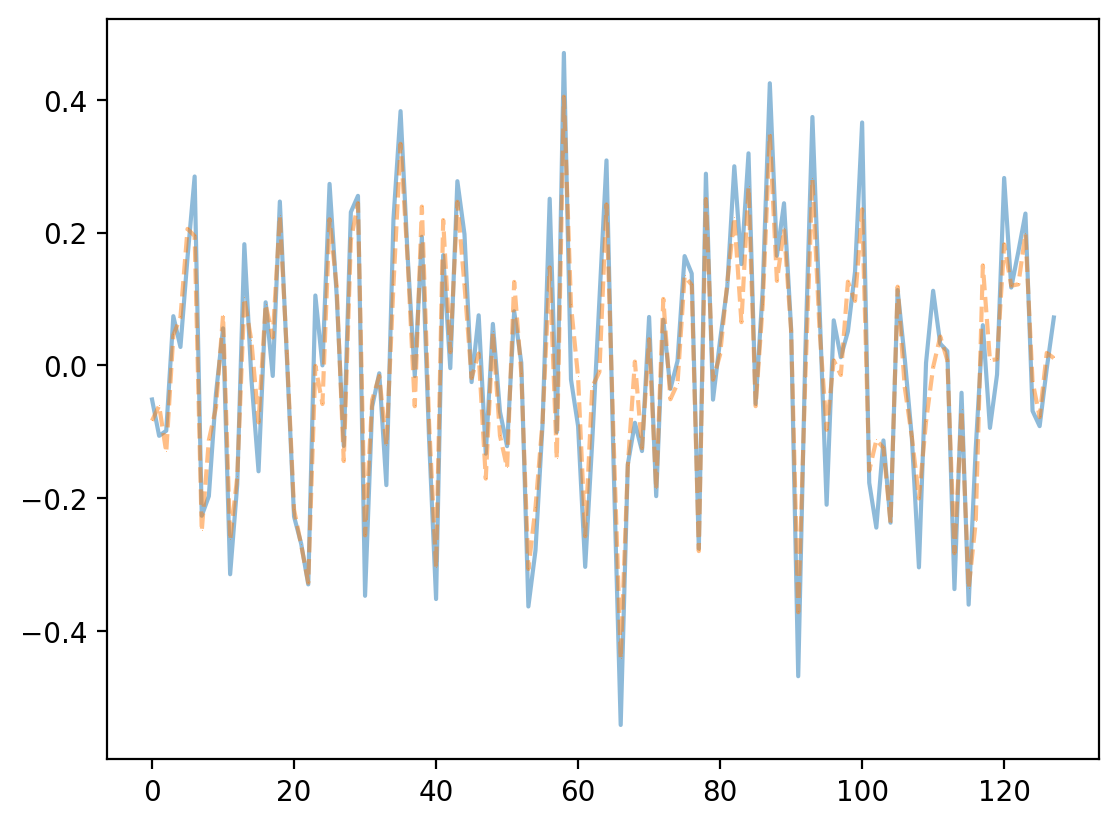

In [61]:
plt.plot(test_graph_dataset.detach().cpu().numpy(), alpha = 0.5)
plt.plot(test_graph_string.detach().cpu().numpy(), '--,', alpha = 0.5)

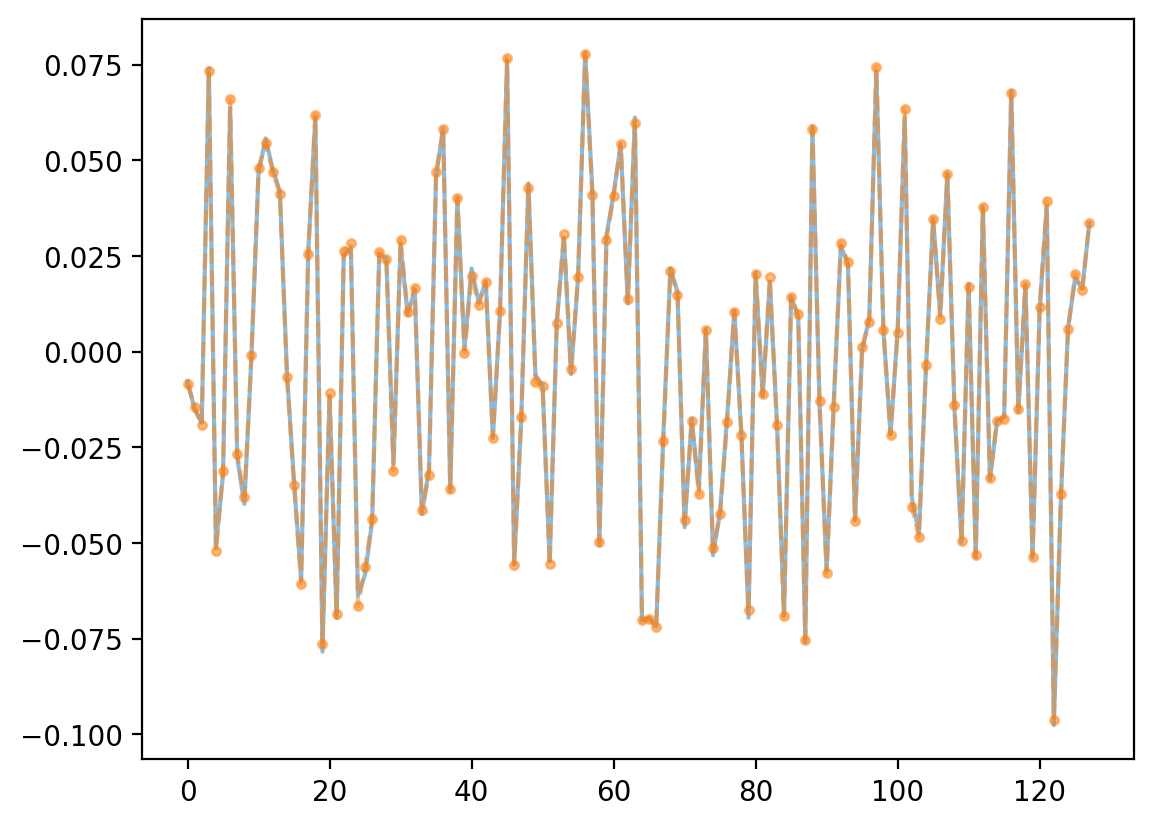

In [62]:
plt.plot(test_bilstm_dataset[0].detach().cpu().numpy(), alpha = 0.5)
plt.plot(test_bilst_string[0].detach().cpu().numpy(), '--.', alpha = 0.5)

In [63]:
print(g.segment_bilstm.shape)
print(d['graph_ready_object'].segment_bilstm.shape)

torch.Size([2, 24])
torch.Size([2, 24])


In [64]:
sorted_x_idxs = np.argsort(y_graph[:,0])
# sorted_x_idxs = np.argsort(y_bilstm[:,0])
print(sorted_x_idxs)
print(chords_list[sorted_x_idxs[0]])
print(chords_list[sorted_x_idxs[-1]])

sorted_y_idxs = np.argsort(y_graph[:,1])
# sorted_y_idxs = np.argsort(y_bilstm[:,1])
print(sorted_y_idxs)
print(chords_list[sorted_y_idxs[0]])
print(chords_list[sorted_y_idxs[-1]])

[112 374 111 ... 778  22 772]
gjt_8_[6, 8]<br>b_G:9_@4_m[1, 4]<br>b_G:9_@4_m[1, 3, 4]<br>
nott_24_[5, 7]<br>b_C:maj_@4_m[0, 4, 7]<br>b_G:maj_@2_m[2]<br>D:min_@2_m[2]<br>
[248 978 986 ... 168 290 127]
gjt_18_[2, 4]<br>b_C:maj_@4_m[4]<br>b_C:7_@4_m[]<br>
gjt_9_[7, 9]<br>b_C:maj6_@2_m[0, 2]<br>B:min7_@1_m[4, 7]<br>E:7_@1_m[0, 9]<br>b_C:maj6_@2_m[0]<br>A#:min7_@1_m[0]<br>D#:7_@1_m[]<br>


In [65]:
graph_seqs = ''

# print left-most
print('left-most chord sequences:')
graph_seqs += 'left-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
graph_seqs += '\n'

# print right-most
print('right-most chord sequences:')
graph_seqs += 'right-most chord sequences:' + '\n'
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1
print('')
graph_seqs += '\n'

# print bottom-most
print('bottom-most chord sequences:')
graph_seqs += 'bottom-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
graph_seqs += '\n'

# print top-most
print('top-most chord sequences:')
graph_seqs += 'top-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1

left-most chord sequences:
G:9  G:9  
B:hdim7  E:7(b9)  
D#:9  G:9  
E:min7  A:9  
A:min11  A:min11  
E:min7  A:13  
D#:7(#11)  D:min7  
A:min11  A:min11  
A:9  A:9  
A:min11  A#:min11  
C:7  G:7  
E:7(b9)  A:min7  
A#:maj7  A#:maj7  
E:7(b9)  A:min7  
G:7  F:7  
E:7(b9)  F:9  
A#:min11  A#:min11  
A:min7  D#:7(#11)  
D:min  G:7  
C:min  D#:9  

right-most chord sequences:
C:maj  G:maj D:min  
G:sus4  G:sus4  
F:maj  C:maj A:min  
G:maj  C:maj  
C:maj  F:maj  
G:maj  C:maj  
A:min E:maj A:min  A:min E:maj A:min  
G:maj  G:maj  
C:maj  C:maj  
F:maj C:maj  G:7 C:maj  
C:maj  C:maj  
F:maj  G:sus4  
C:maj  C:maj  
C:maj A:min  D:min G:maj  
F:maj  F:maj  
F:maj  C:maj  
C:maj  A:min  
G:7 C:maj  C:maj  
C:maj  A:min  
C:maj A#:maj  C:maj  

bottom-most chord sequences:
C:maj  C:7  
A#:maj  F:maj  
C:maj  A#:maj  
C:7  C:7  
A#:maj  C:maj  
C:maj  A#:maj  
A#:maj  A#:maj  
F:maj  C:7  
G:min7  C:9  
A#:sus4  E:min7  
G:min7  C:7  
G:sus4  G:7  
C:maj  C:7  
C:maj  C:maj  
A:min6  G:min7  

In [66]:
print(graph_seqs)

left-most chord sequences:
G:9  G:9  
B:hdim7  E:7(b9)  
D#:9  G:9  
E:min7  A:9  
A:min11  A:min11  
E:min7  A:13  
D#:7(#11)  D:min7  
A:min11  A:min11  
A:9  A:9  
A:min11  A#:min11  
C:7  G:7  
E:7(b9)  A:min7  
A#:maj7  A#:maj7  
E:7(b9)  A:min7  
G:7  F:7  
E:7(b9)  F:9  
A#:min11  A#:min11  
A:min7  D#:7(#11)  
D:min  G:7  
C:min  D#:9  

right-most chord sequences:
C:maj  G:maj D:min  
G:sus4  G:sus4  
F:maj  C:maj A:min  
G:maj  C:maj  
C:maj  F:maj  
G:maj  C:maj  
A:min E:maj A:min  A:min E:maj A:min  
G:maj  G:maj  
C:maj  C:maj  
F:maj C:maj  G:7 C:maj  
C:maj  C:maj  
F:maj  G:sus4  
C:maj  C:maj  
C:maj A:min  D:min G:maj  
F:maj  F:maj  
F:maj  C:maj  
C:maj  A:min  
G:7 C:maj  C:maj  
C:maj  A:min  
C:maj A#:maj  C:maj  

bottom-most chord sequences:
C:maj  C:7  
A#:maj  F:maj  
C:maj  A#:maj  
C:7  C:7  
A#:maj  C:maj  
C:maj  A#:maj  
A#:maj  A#:maj  
F:maj  C:7  
G:min7  C:9  
A#:sus4  E:min7  
G:min7  C:7  
G:sus4  G:7  
C:maj  C:7  
C:maj  C:maj  
A:min6  G:min7  

In [67]:
# sorted_x_idxs = np.argsort(y_graph[:,0])
sorted_x_idxs = np.argsort(y_bilstm[:,0])
print(sorted_x_idxs)
print(chords_list[sorted_x_idxs[0]])
print(chords_list[sorted_x_idxs[-1]])

# sorted_y_idxs = np.argsort(y_graph[:,1])
sorted_y_idxs = np.argsort(y_bilstm[:,1])
print(sorted_y_idxs)
print(chords_list[sorted_y_idxs[0]])
print(chords_list[sorted_y_idxs[-1]])

[367 271 493 ... 741 210 211]
gjt_26_[5, 7]<br>b_A:min7_@4_m[9, 2, 4, 7]<br>b_E:sus4_@4_m[4]<br>
gjt_15_[7, 9]<br>b_A:min7_@1_m[0]<br>D:7_@1_m[0]<br>G:min7_@1_m[0]<br>C:7_@1_m[0]<br>b_F:maj6_@2_m[5]<br>B:hdim7_@1_m[5]<br>E:7_@1_m[4]<br>
[108  22 421 ... 473 194 216]
gjt_8_[2, 4]<br>b_E:min7_@2_m[2, 7]<br>D#:7_@2_m[7]<br>b_G#:maj7_@2_m[7]<br>G:7_@2_m[7]<br>
gjt_15_[12, 14]<br>b_B:hdim7_@2_m[4]<br>E:7(b9)_@2_m[4]<br>b_A:min_@2_m[0, 9, 11]<br>A:minmaj7_@2_m[9, 4]<br>


In [68]:
bilstm_seqs = ''

# print left-most
print('left-most chord sequences:')
bilstm_seqs += 'left-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
bilstm_seqs += '\n'

# print right-most
print('right-most chord sequences:')
bilstm_seqs += 'right-most chord sequences:' + '\n'
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1
print('')
bilstm_seqs += '\n'

# print bottom-most
print('bottom-most chord sequences:')
bilstm_seqs += 'bottom-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
bilstm_seqs += '\n'

# print top-most
print('top-most chord sequences:')
bilstm_seqs += 'top-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1

left-most chord sequences:
A:min7  E:sus4  
C:maj7  F:maj7  
A:min  A:min  
C:maj  C:maj  
F#:hdim7  E:sus4  
C:maj  C:maj  
C:7  C:7  
C:maj  A:min  
C:maj  C:maj  
F:maj7  E:maj  
C:maj  C:maj  
C:maj  C:7  
C:maj  F:maj  
C:maj6  C:maj6  
C:maj7  F:9  
C:maj  C:maj  
A:min  A:min  
C:maj  C:maj  
C:maj  F:maj  
E:sus4  C:maj7  

right-most chord sequences:
A:min7 D:7 G:min7 C:7  F:maj6 B:hdim7 E:7  
G:min7 C:7  A:min7 D:7 G:min7 C:7  
A:min E:maj A:min  A:min E:maj A:min  
A#:maj7 A:aug  G:min7 C:7 B:7  
C:maj6 B:min7 E:7  C:maj6 A#:min7 D#:7  
E:maj6 F#:min7 B:7  E:maj6 C:min7 F:7  
E:maj7 F#:min7 B:sus4  E:maj6 F#:min7 B:7  
D:min7 G:7(b9)  C:maj6 B:min7 E:7  
G:min7 C:7 C#:dim  D:min7 A#:maj7  
A:min7 D:7  G:maj7 D:min7 G:7  
G:maj7 D:min7 G:7  C:maj7 F:9  
E:maj7 B:min7 E:7  D#:min7 G#:7  
F:maj7 D:min7  G:min7 C:7 C#:dim  
A:min7 D:7  G:min7 C:7 C#:dim  
G:min7 C:7 C#:dim  D:min7 G:7  
G:maj6 C:maj6  G:maj6 D:min7 G:7  
C:maj6 A#:min7 D#:7  G#:maj7 F:min7  
F#:min7 B:7(b13)  E:

In [69]:
print(bilstm_seqs)

left-most chord sequences:
A:min7  E:sus4  
C:maj7  F:maj7  
A:min  A:min  
C:maj  C:maj  
F#:hdim7  E:sus4  
C:maj  C:maj  
C:7  C:7  
C:maj  A:min  
C:maj  C:maj  
F:maj7  E:maj  
C:maj  C:maj  
C:maj  C:7  
C:maj  F:maj  
C:maj6  C:maj6  
C:maj7  F:9  
C:maj  C:maj  
A:min  A:min  
C:maj  C:maj  
C:maj  F:maj  
E:sus4  C:maj7  

right-most chord sequences:
A:min7 D:7 G:min7 C:7  F:maj6 B:hdim7 E:7  
G:min7 C:7  A:min7 D:7 G:min7 C:7  
A:min E:maj A:min  A:min E:maj A:min  
A#:maj7 A:aug  G:min7 C:7 B:7  
C:maj6 B:min7 E:7  C:maj6 A#:min7 D#:7  
E:maj6 F#:min7 B:7  E:maj6 C:min7 F:7  
E:maj7 F#:min7 B:sus4  E:maj6 F#:min7 B:7  
D:min7 G:7(b9)  C:maj6 B:min7 E:7  
G:min7 C:7 C#:dim  D:min7 A#:maj7  
A:min7 D:7  G:maj7 D:min7 G:7  
G:maj7 D:min7 G:7  C:maj7 F:9  
E:maj7 B:min7 E:7  D#:min7 G#:7  
F:maj7 D:min7  G:min7 C:7 C#:dim  
A:min7 D:7  G:min7 C:7 C#:dim  
G:min7 C:7 C#:dim  D:min7 G:7  
G:maj6 C:maj6  G:maj6 D:min7 G:7  
C:maj6 A#:min7 D#:7  G#:maj7 F:min7  
F#:min7 B:7(b13)  E:

In [70]:
from ollama import chat
from ollama import ChatResponse

response: ChatResponse = chat(model='qwen2.5-coder:7b', messages=[
  {
    'role': 'user',
    'content': 'Can you commend on sequences of musical chords? \
        For example, which chord sequence is more common: a) G:7 C:maj7 or b)C#:7 C:maj7?',
  },
])
print(response['message']['content'])
# or access fields directly from the response object
# print(response.message.content)

Both G:7 (G dominant 7th chord) and C#:7 (C# dominant 7th chord) are commonly used in jazz and other forms of music. However, their usage can vary depending on the context and the musical style you're working with.

1. **G:7**:
   - This chord is often used as a turnaround or to move from one section of a piece to another.
   - It's common in many pop, rock, and jazz compositions.
   - The G dominant 7th chord can also be used as an ii-v-i progression in the key of C (Cm - F - G).

2. **C#:7**:
   - This is often referred to as the "C# Blues" chord.
   - It's frequently used in blues, jazz, and rock music.
   - The C# dominant 7th chord can be part of a ii-v-i progression in the key of F (Dm - Bb - C#).

### Commonality:
Both chords are commonly used in their respective genres. However, they might be more frequently encountered in certain musical contexts:

- **G:7** is often seen as a smoother and less dissonant chord compared to C#:7.
- **C#:7** can add a bit of tension and excitemen

In [71]:
response: ChatResponse = chat(model='qwen2.5-coder:7b', messages=[
  {
    'role': 'user',
    'content': f'You are a music harmony expert and you role is to provide \
    comments on chord progressions that appear within two PCA-projected spaces. \
    These PCA spaces were produced by two models that process symbolic music \
    harmony and we are interested in explaining whether there is something \
    specific that the first two axes represent (left-right and bottom-top). \
    These spaces were formed by the same short chord sequences and we only use \
    the ones on the extreme edges in the analysis.\
    We are interested in understanding if Model 1 or Model 2 \
    have generated more musically meaningful representations and which one is better. \
    Keep in mid that both Models are trained on pieces in C major and A minor \
    and that the sequences they processes are segments of C major - A minor pieces. \
    Below are the Sets positioned in the respective PCA spaces by each model. \
    Here is Set 1: `{bilstm_seqs}`. \n\n \
    Here is Set 2: `{graph_seqs}`.\n \
    If you had to pick a model, who would that be and why?',
  },
])
print(response['message']['content'])

To determine which model generates more musically meaningful representations based on the PCA projections of chord progressions, we can analyze the structure and characteristics of the sets in each model's space. Here’s how I would evaluate them:

### Set 1 Analysis:

**Left-most (A: Min7, E: Sus4):**
- These are common dominant chords that often precede tonic chords or form a modal progression.
- The leftmost set shows a balance between minor and major progressions, indicating flexibility.

**Right-most (G:9, A: Min11):**
- More complex extended dominants and minor extensions, suggesting a more advanced harmonic language.
- This set also includes several augmented chords (A: Aug), which can indicate a strong sense of chromaticism and tension resolution.

**Bottom-most (E: Min7, G: Min7 C: 9):**
- Predominantly minor with a few extended chords, showing a rich progression in the minor key.
- The bottom set is more conservative compared to the left and right sets but still shows complexi